In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T, models
from sklearn.model_selection import train_test_split
from PIL import Image
from collections import Counter
from tqdm import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import matplotlib.pyplot as plt


In [2]:
# PARAMS
BATCH_SIZE = 8
EPOCHS = 40
criterion = nn.BCEWithLogitsLoss()
LEARNING_RATE = 0.00003

In [3]:
def plot_training_curves(train_losses, val_losses, train_maes, val_maes, save_path = './plots/learning_curve.png'):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))

    # Loss 
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o', color='#414141')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o', color='#8FA31E')
    plt.title('Loss por Época', fontsize=14)
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # MAE 
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_maes, label='Train MAE', marker='o', color='#414141')
    plt.plot(epochs, val_maes, label='Validation MAE', marker='o', color='#8FA31E')
    plt.title('MAE por Época', fontsize=14)
    plt.xlabel('Época')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(save_path, dpi = 150)
    # plt.show()


In [4]:
df = pd.read_parquet('./UTKFACE_dataset.parquet')
df.head()

,image_path,age,gender,race,race_decoded,gender_decoded
19,./UTKFACE/10_0_0_20161220222308131.jpg,10,0,0,White,Male
20,./UTKFACE/10_0_0_20170103200329407.jpg,10,0,0,White,Male
21,./UTKFACE/10_0_0_20170103200522151.jpg,10,0,0,White,Male
22,./UTKFACE/10_0_0_20170103233459275.jpg,10,0,0,White,Male
23,./UTKFACE/10_0_0_20170104013211746.jpg,10,0,0,White,Male


In [5]:
# Split estratificado por edad, mantenemos el desbalance todo el momento.
# Train -> 80%
# Validation -> 10%
# Test -> 10%

train_df, temp_df = train_test_split(df, test_size = 0.20, stratify = df['age'], random_state = 42)

val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify = temp_df['age'], random_state = 42)

print(f"""
Train:\t{len(train_df)}
Validation:\t{len(val_df)}
Test:\t{len(test_df)}
""")



Train:	16308
Validation:	2038
Test:	2039



In [6]:
train_transform = T.Compose([
    T.Resize((244, 244)),
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),  
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),  
    T.RandomRotation(15),  
    T.RandomApply([T.GaussianBlur(3)], p=0.2),  # reduce prob
    T.RandomGrayscale(p=0.25),  
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((244, 244)),
    T.ToTensor(),
    T.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
])


In [7]:
"""
CORAL = Consistent ORdinal Regression for Labeling
La edad NO es una categoria independiente, es ordinal (30 esta cerca de 31, pero lejos de 5).
Entonces en vez de tratar la edad con softmax (que asume categorias independientes), CORAL transforma el problema en multiples comparaciones binarias ordenadas.
---
Ejemplo: edad = 5 -> [1,1,1,1,1,0,0,0,0....AgeMax]
                     [1,2,3,4,5,6,7,8,9,...AgeMax]
"""

# CORAL Encoding
def age_to_ordinal(age, max_age=80):
    return torch.tensor([1 if age > i else 0 for i in range(max_age)], dtype=torch.float32)


In [ ]:
class AgeDataset(Dataset):
    
    def __init__(self, df, transform, max_age = 80):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.max_age = max_age

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row.image_path).convert("RGB")
        img = self.transform(img)
        target = age_to_ordinal(row.age, self.max_age)
        return img, target

    def __len__(self):
        return len(self.df)


class CoralEfficientNetV2(nn.Module):
    def __init__(self, max_age=80):
        super().__init__()
        self.max_age = max_age
        
        self.backbone = models.efficientnet_v2_l(weights='IMAGENET1K_V1')

        # Congelar todo excepto ultimas 2 capas (features.6 y features.7)
        for name, param in self.backbone.named_parameters():
            if "features.6" not in name and "features.7" not in name:
                param.requires_grad = False
        
        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),     
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),         
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),     
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),        
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),        
            nn.Linear(128, max_age)
        )

    def forward(self, x):
        return self.backbone(x)
    
# Los logits (prediccion del modelo), los pasamos por sigmoide
def predict_age(logits):
    probs = torch.sigmoid(logits)
    return (probs > 0.5).sum(dim=1)


In [9]:
# WeightedRandomSampler para balancear en train, es decir, para que cada epoca, el dataloader cargue de forma sampleada

counts = Counter(train_df['age'])
weights = torch.tensor([1.0 / counts[i] for i in train_df['age']], dtype=torch.float32)
sampler = WeightedRandomSampler(weights, num_samples = len(weights), replacement=True)


In [10]:
train_loader = DataLoader(
    AgeDataset(train_df, train_transform),
    batch_size = BATCH_SIZE,
    sampler = sampler,
    num_workers = 4
)

val_loader = DataLoader(
    AgeDataset(val_df, val_transform),
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 4
)

test_loader = DataLoader(
    AgeDataset(test_df, val_transform),
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 4
)


In [ ]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    total_mae = 0
    
    progress_bar = tqdm(loader, desc="Training", leave = False, unit = 'batch')
    for imgs, targets in progress_bar:
        imgs, targets = imgs.to(device), targets.to(device)

        logits = model(imgs)
        loss = criterion(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        pred_age = predict_age(logits)
        true_age = targets.sum(dim=1)  

        batch_mae = torch.abs(pred_age - true_age).float().mean()

        total_loss += loss.item()
        total_mae += batch_mae.item()
        progress_bar.set_postfix({
            "batch_loss": f"{loss.item():.4f}"
        })

    return total_loss / len(loader), total_mae / len(loader)


def val_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    total_mae = 0

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Validating", leave=False, unit = 'batch'):
            imgs, targets = imgs.to(device), targets.to(device)
            logits = model(imgs)
            loss = criterion(logits, targets)

            pred_age = predict_age(logits)
            true_age = targets.sum(dim=1)

            mae = torch.abs(pred_age - true_age).float().mean()

            total_loss += loss.item()
            total_mae += mae.item()

    return total_loss / len(loader), total_mae / len(loader)


Epoca 1/40


Train Loss: 0.4016	Train MAE: 13.1878
Val Loss: 0.2322	Val MAE: 6.8636
Learning Rate: 0.000030

Epoca 2/40


Train Loss: 0.2639	Train MAE: 8.8062
Val Loss: 0.1962	Val MAE: 6.5580
Learning Rate: 0.000030

Epoca 3/40


Train Loss: 0.2375	Train MAE: 7.8742
Val Loss: 0.2112	Val MAE: 7.5008
Learning Rate: 0.000030

Epoca 4/40


Train Loss: 0.2249	Train MAE: 7.4332
Val Loss: 0.1866	Val MAE: 6.4444
Learning Rate: 0.000030

Epoca 5/40


...

Train Loss: 0.0965	Train MAE: 3.2583
Val Loss: 0.1749	Val MAE: 5.4467
Learning Rate: 0.000030

Epoca 37/40


Train Loss: 0.0957	Train MAE: 3.2056
Val Loss: 0.1748	Val MAE: 5.4783
Learning Rate: 0.000030

Epoca 38/40


Train Loss: 0.0931	Train MAE: 3.1557
Val Loss: 0.1851	Val MAE: 5.5850
Learning Rate: 0.000030

Epoca 39/40


Train Loss: 0.0927	Train MAE: 3.0929
Val Loss: 0.1682	Val MAE: 5.1520
Learning Rate: 0.000030

Epoca 40/40


Train Loss: 0.0911	Train MAE: 3.0666
Val Loss: 0.1734	Val MAE: 5.3185
Learning Rate: 0.000030



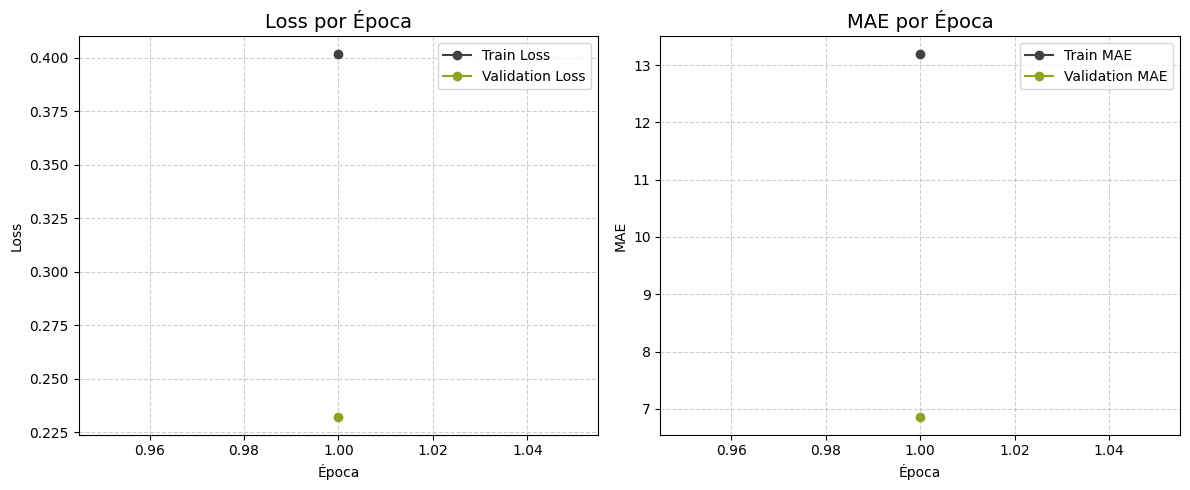

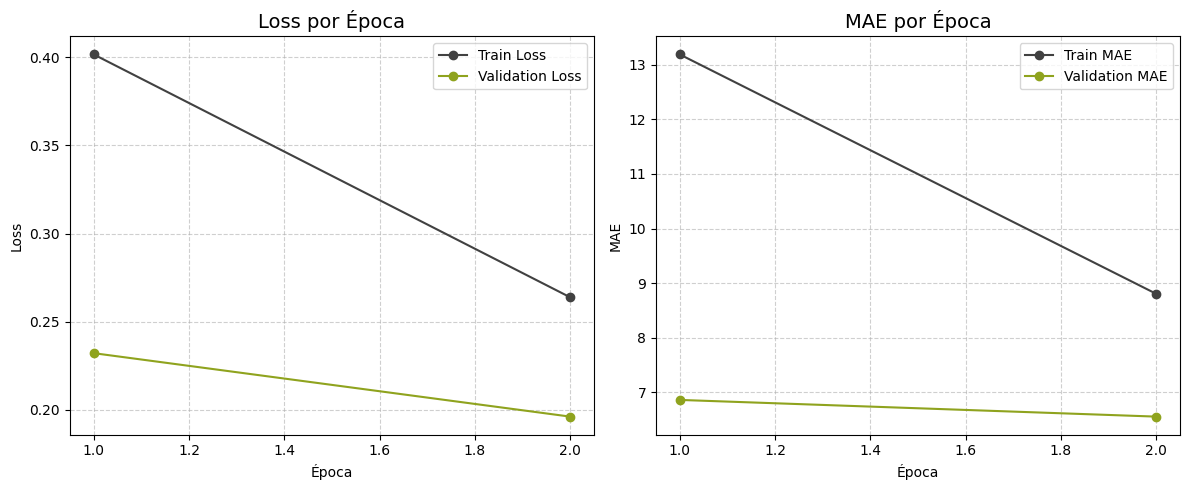

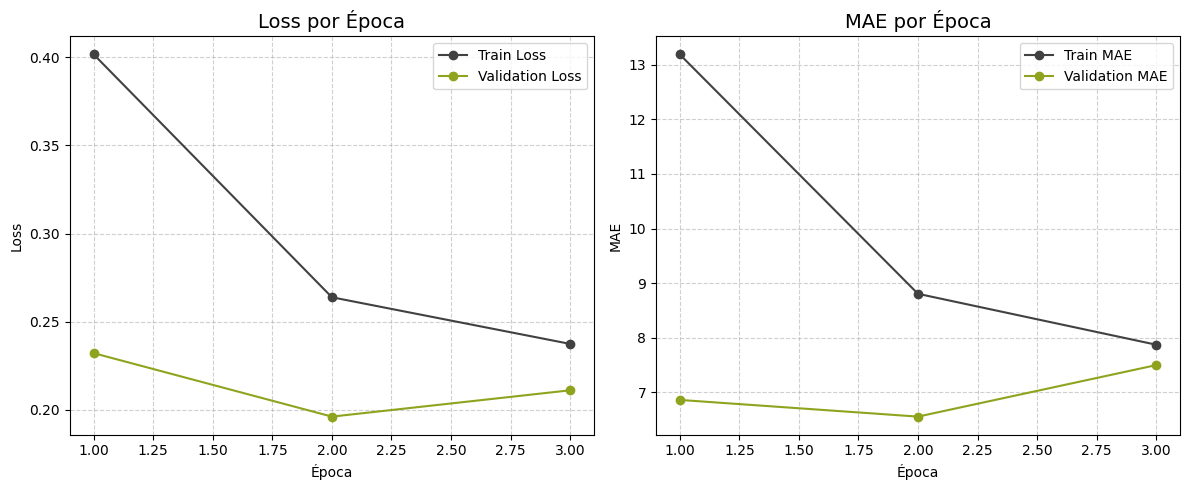

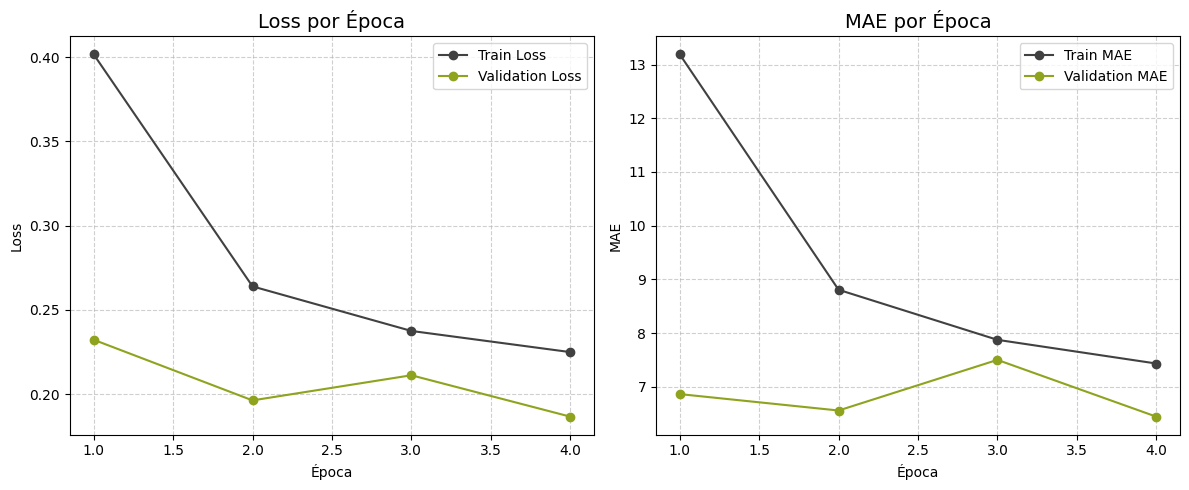

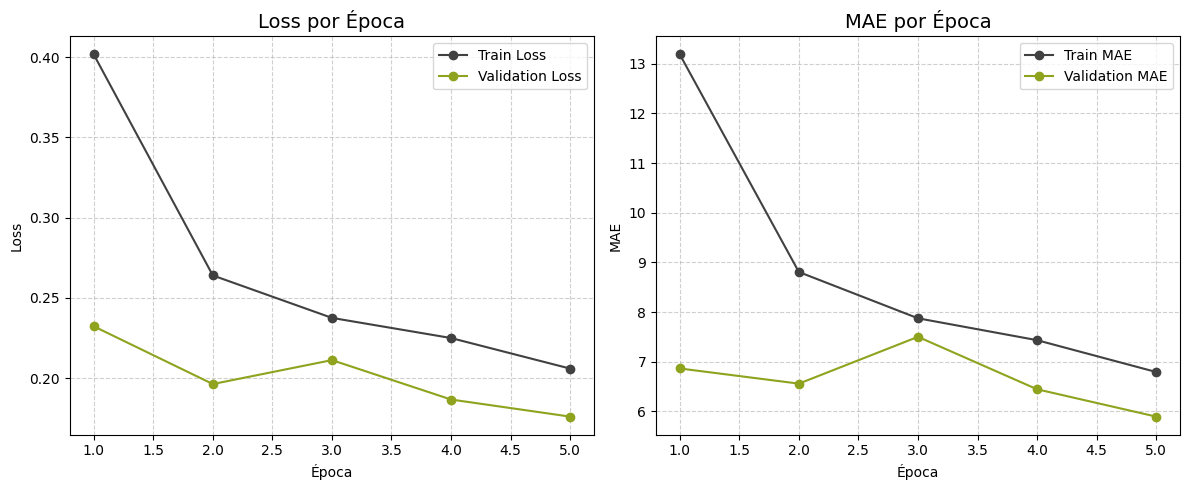

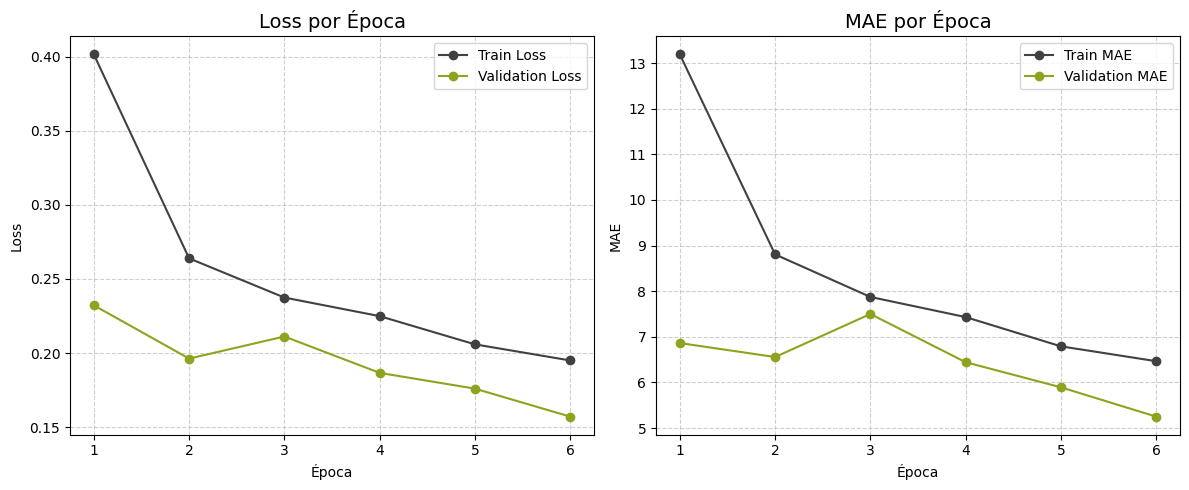

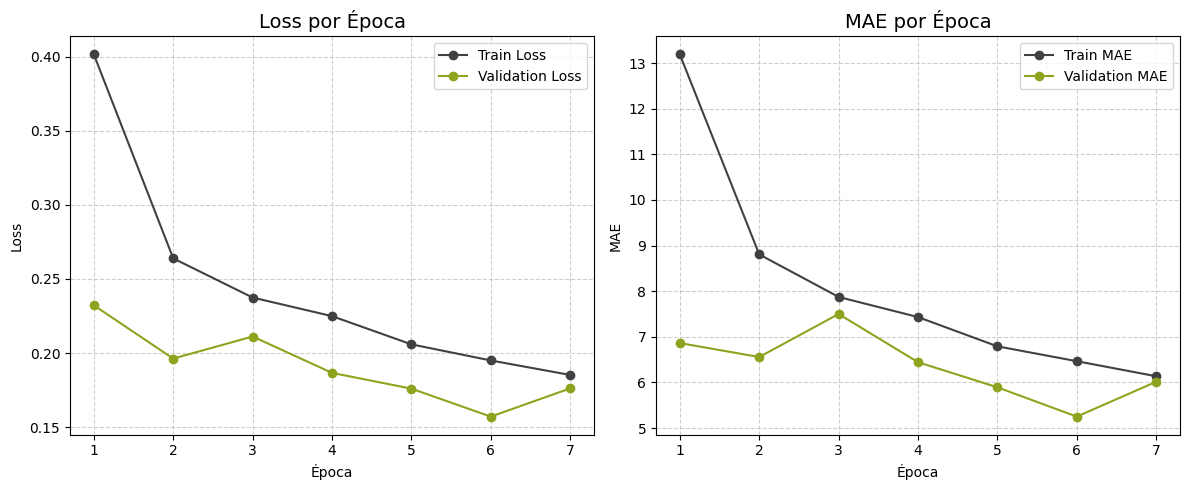

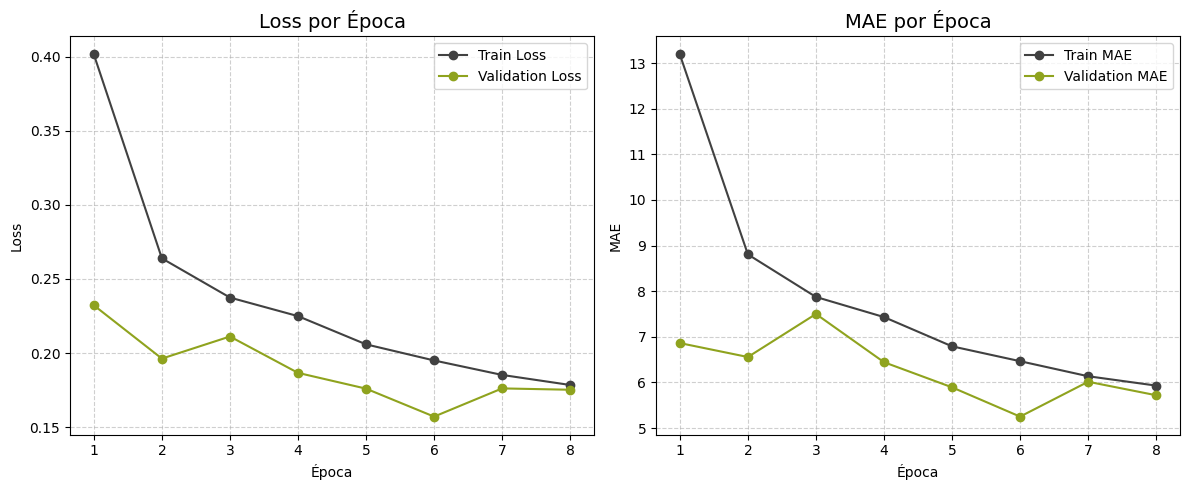

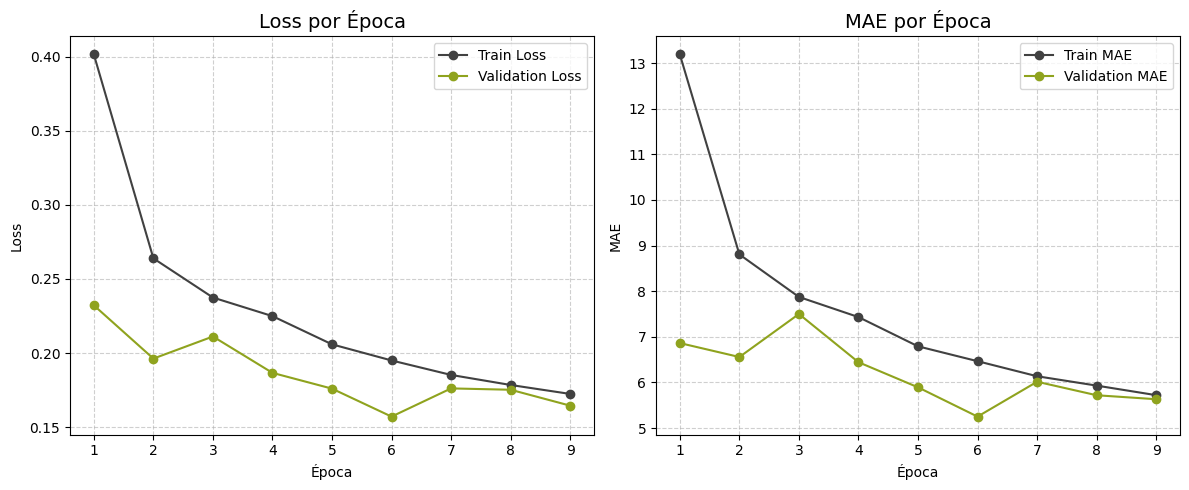

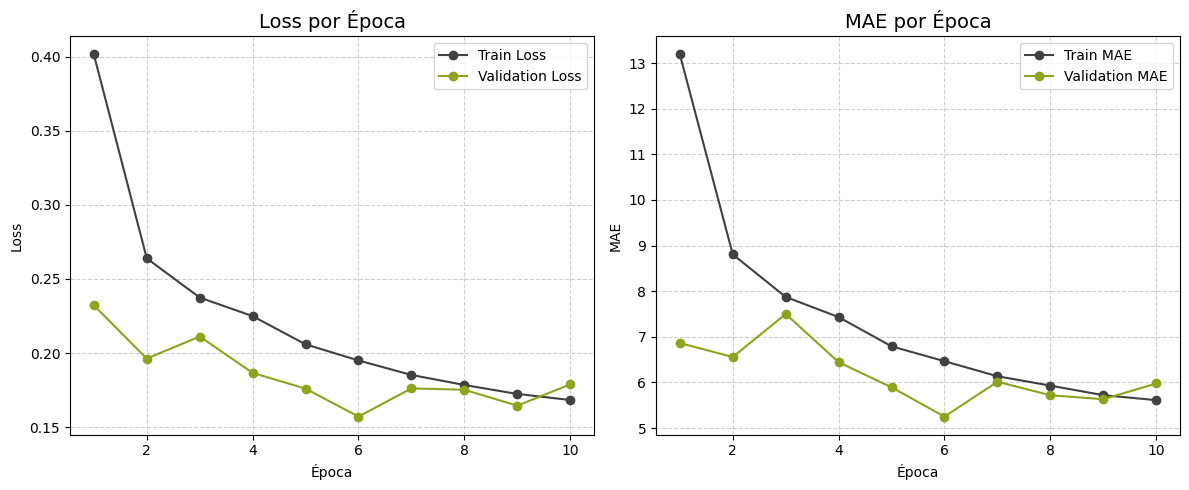

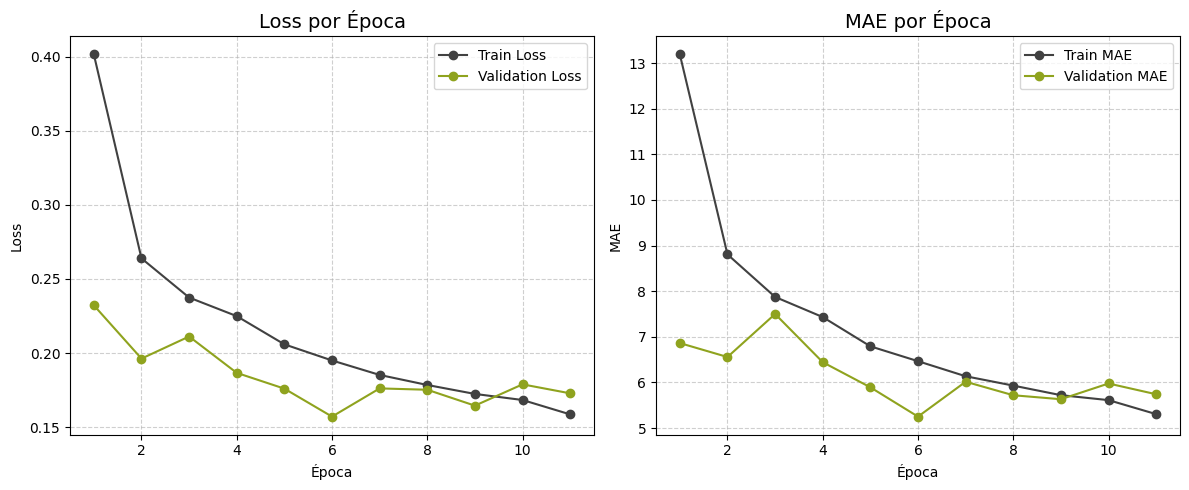

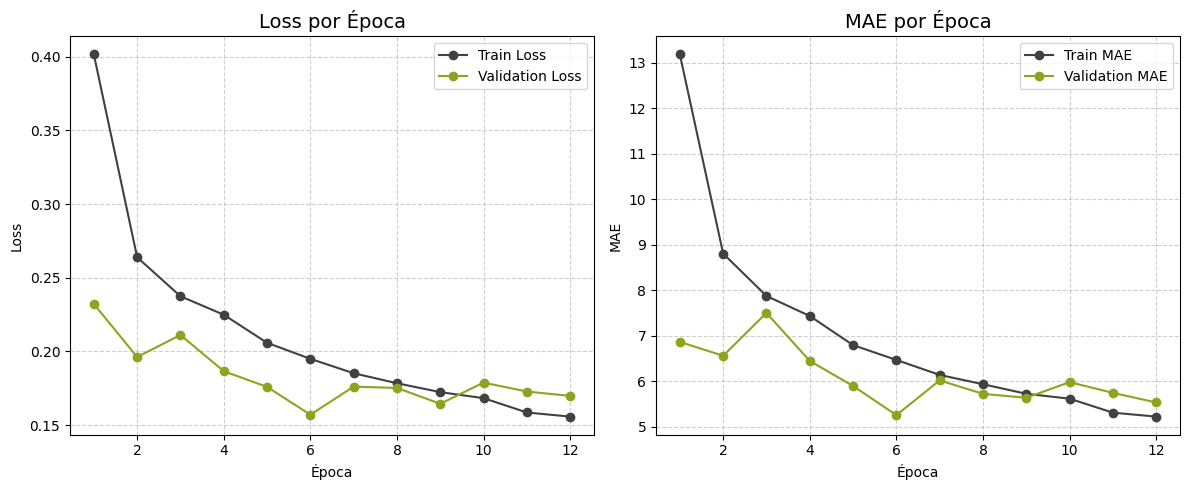

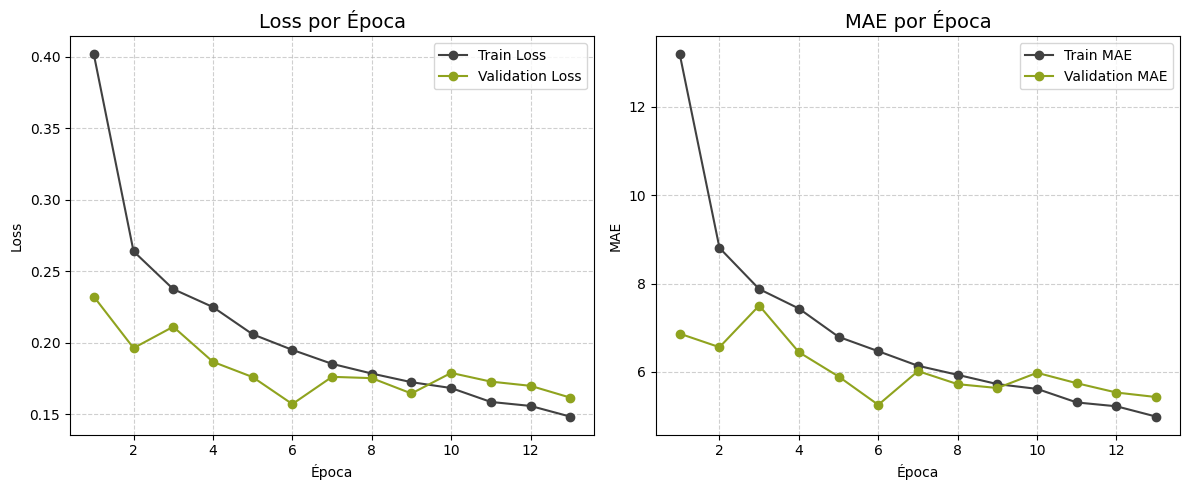

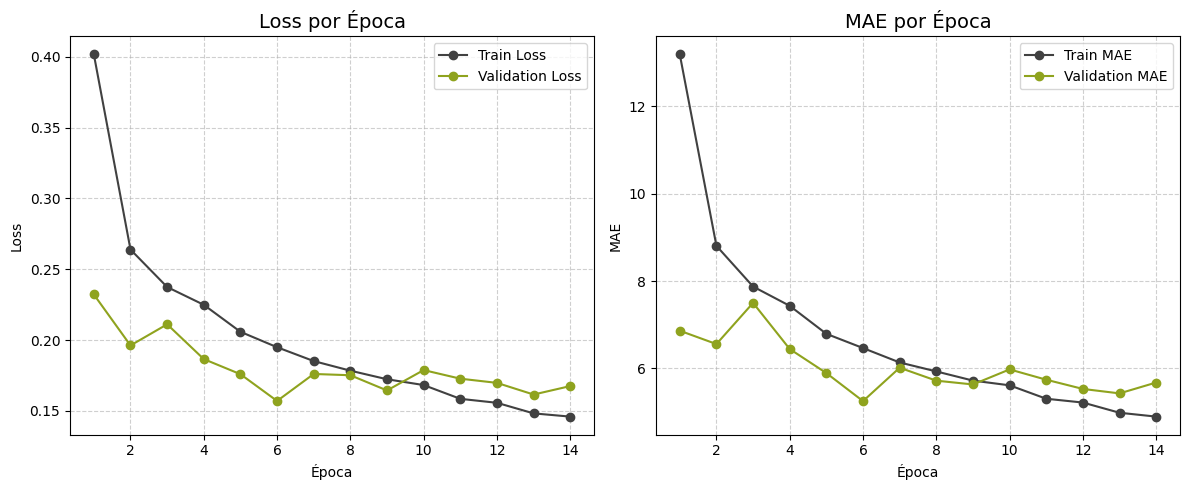

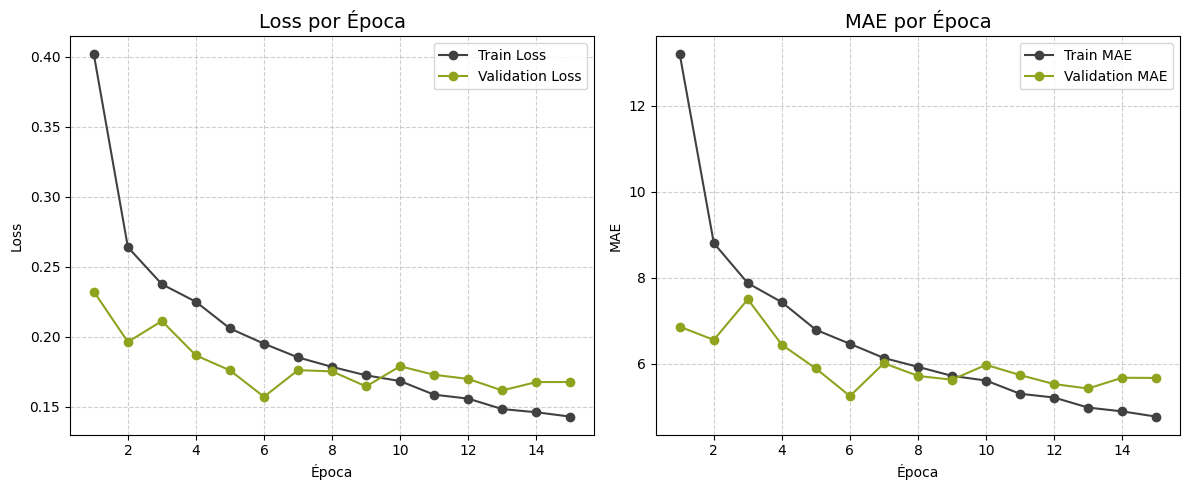

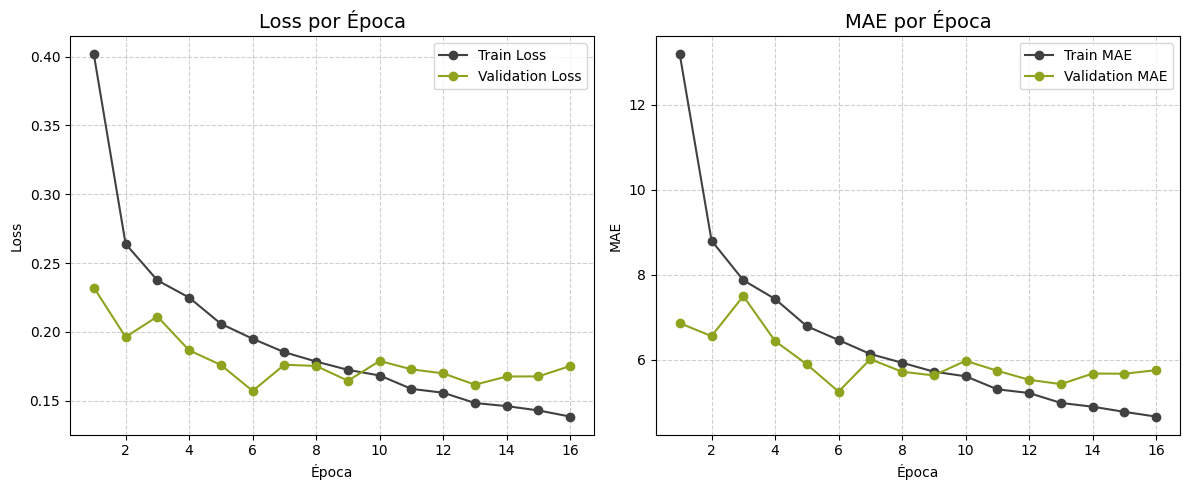

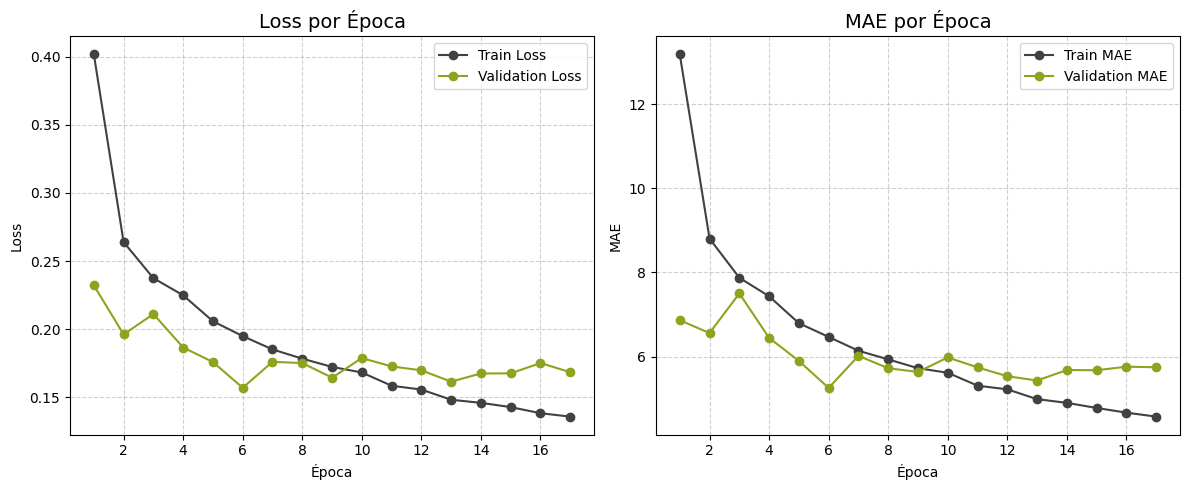

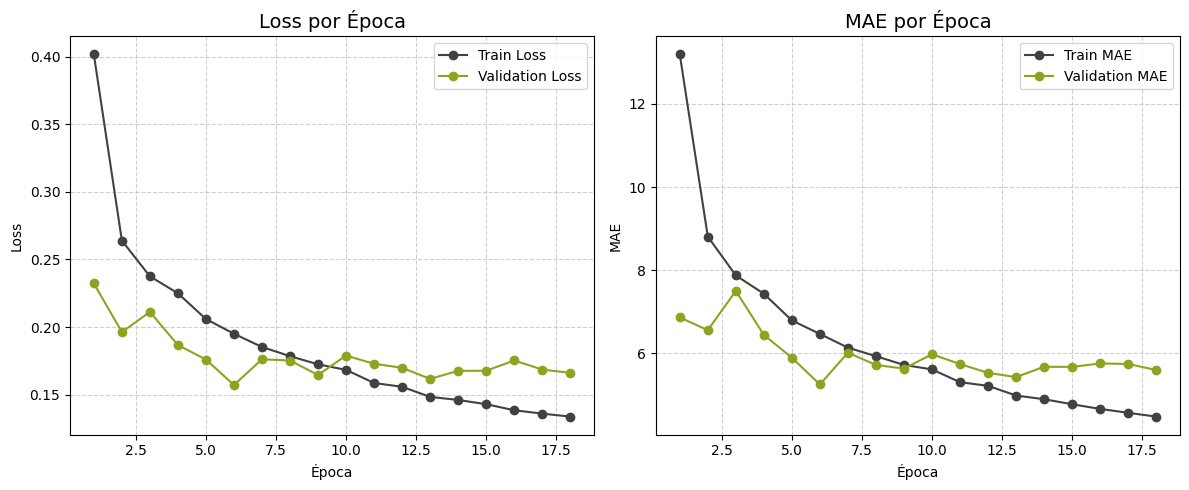

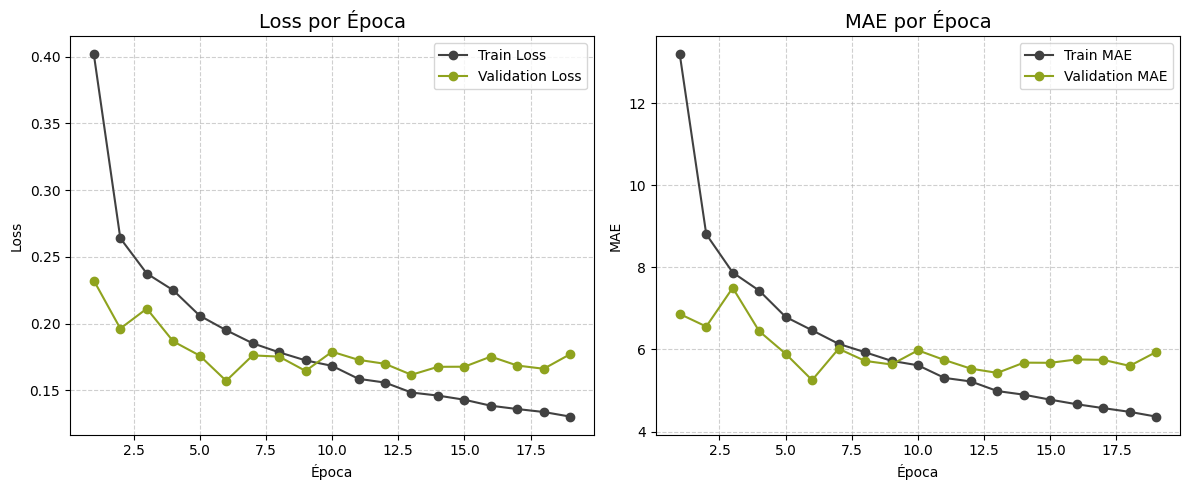

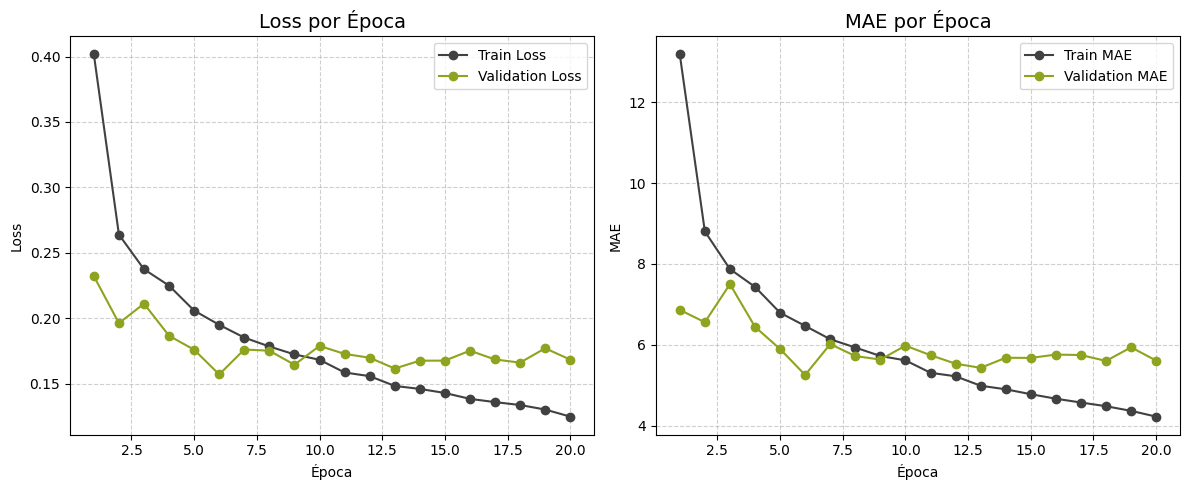

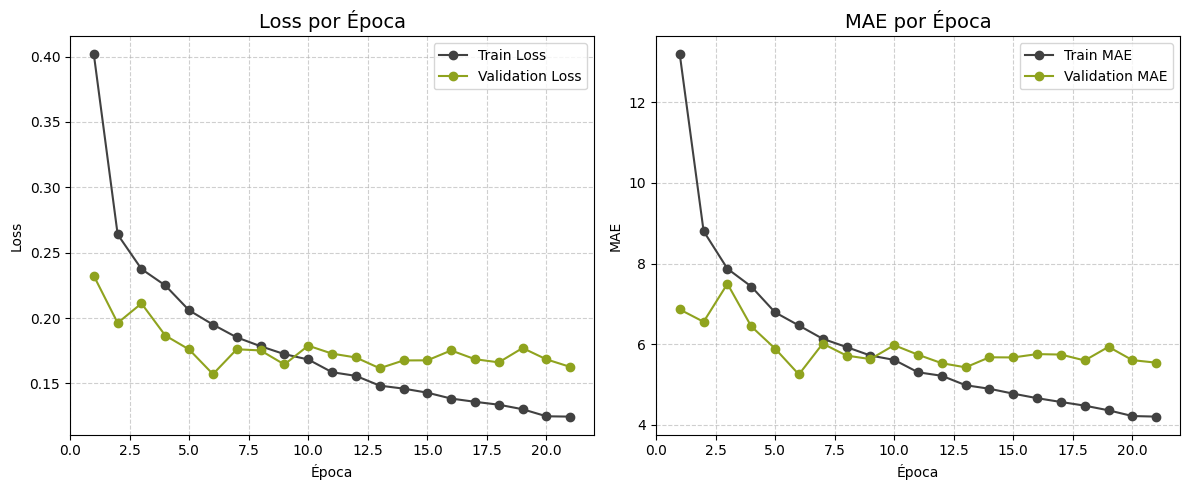

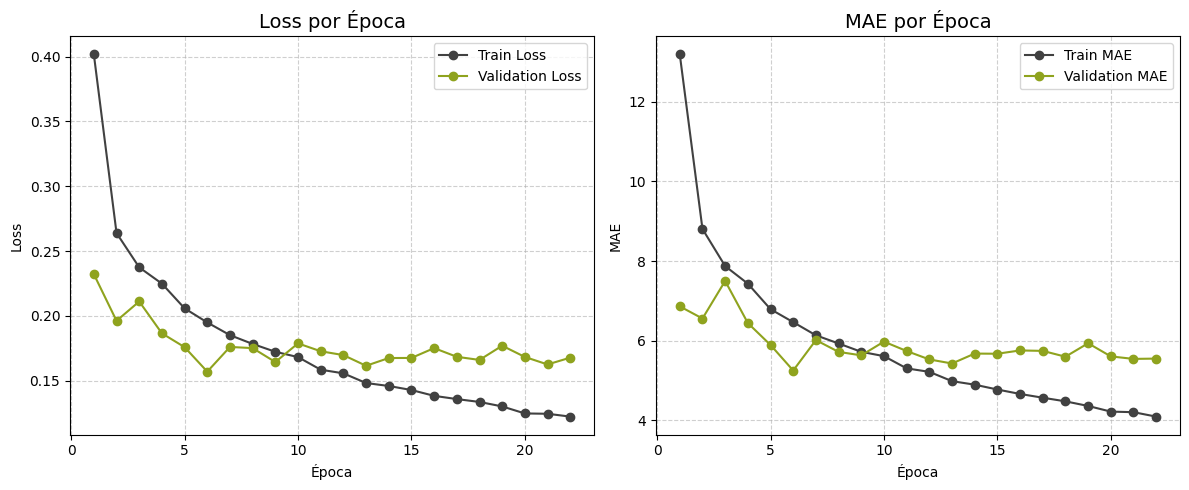

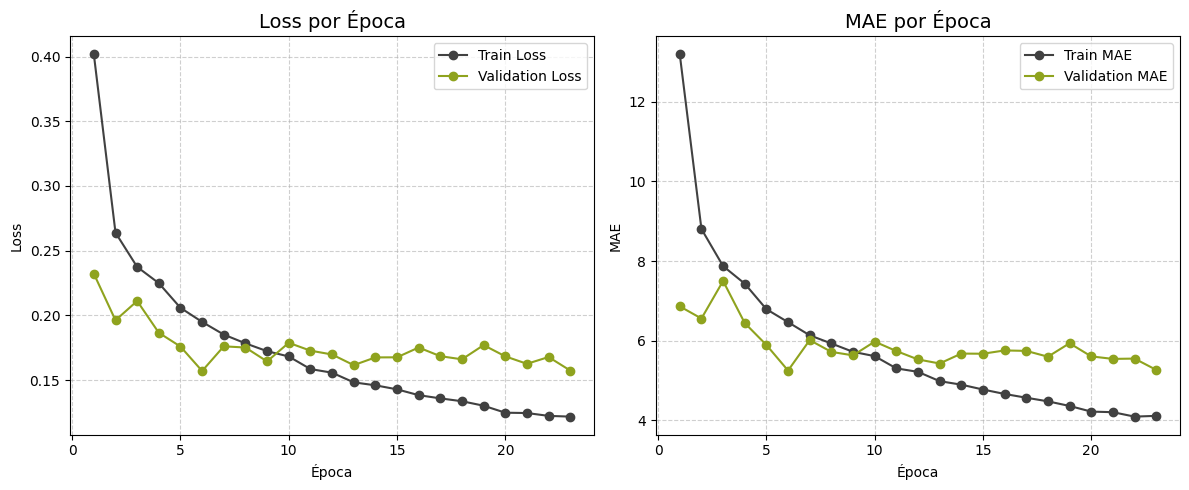

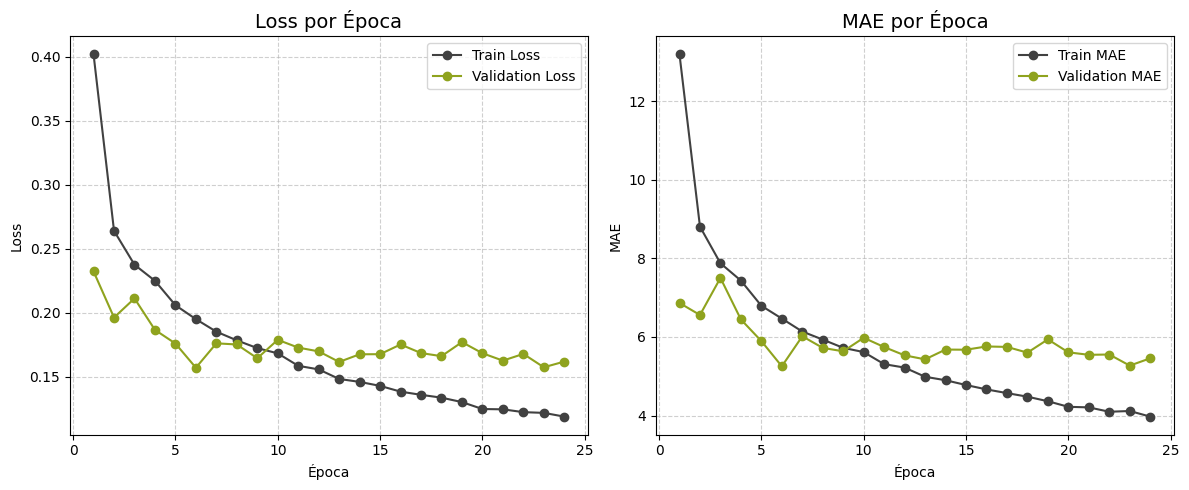

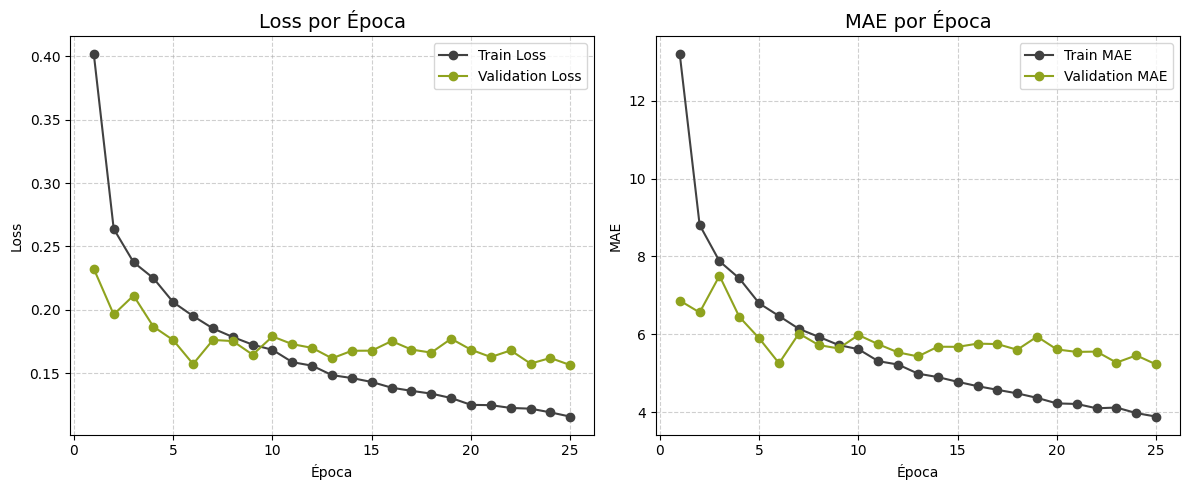

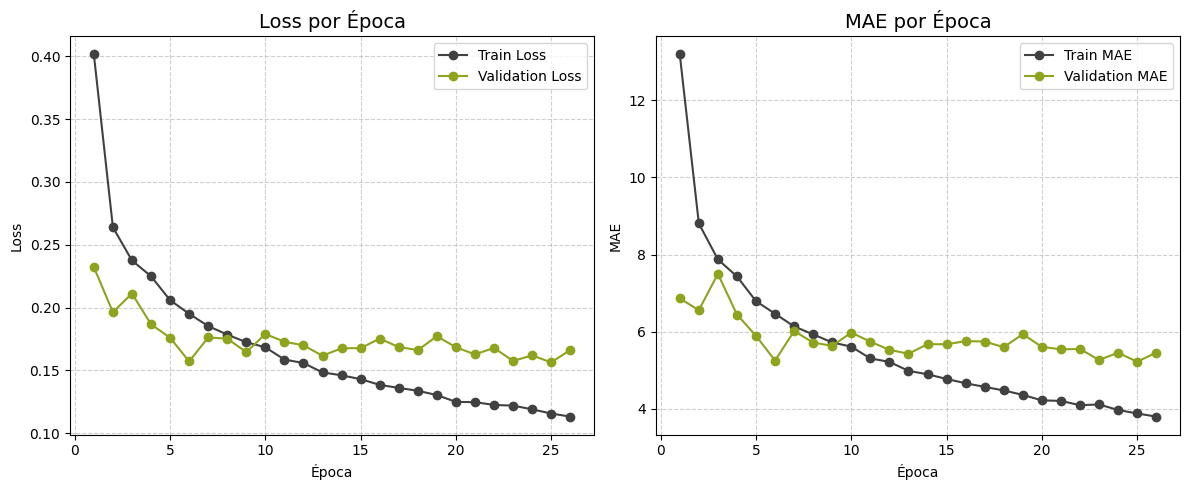

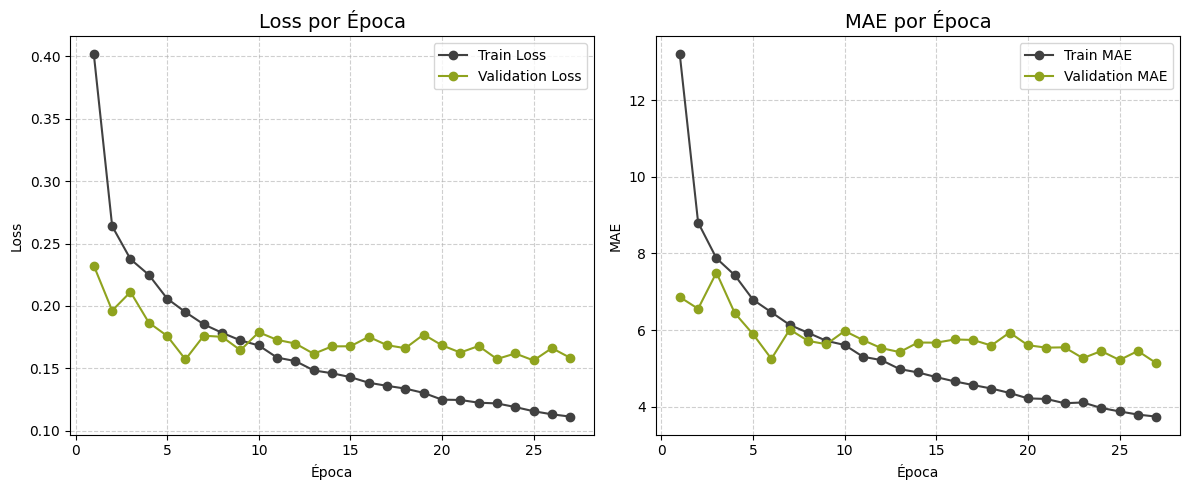

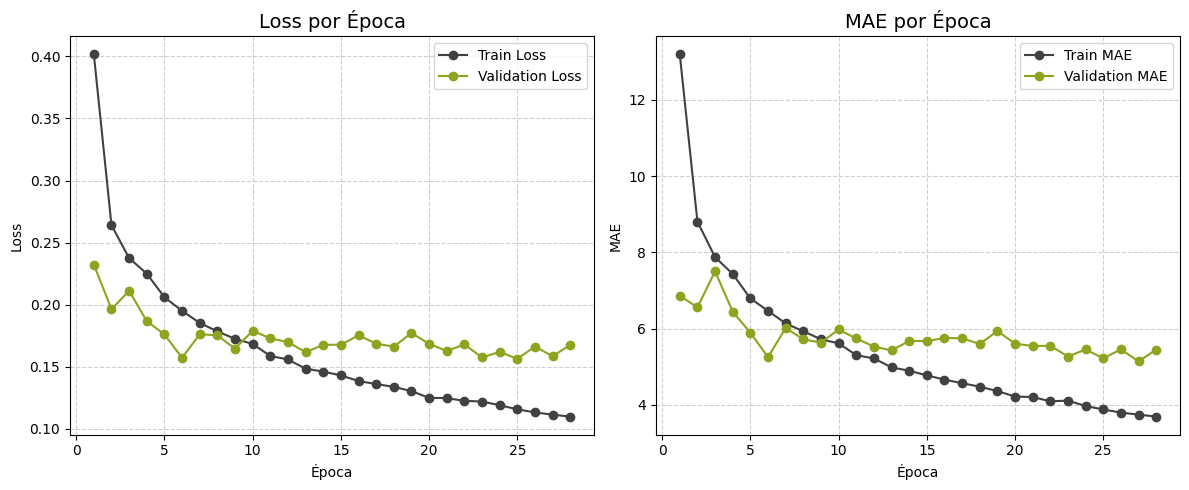

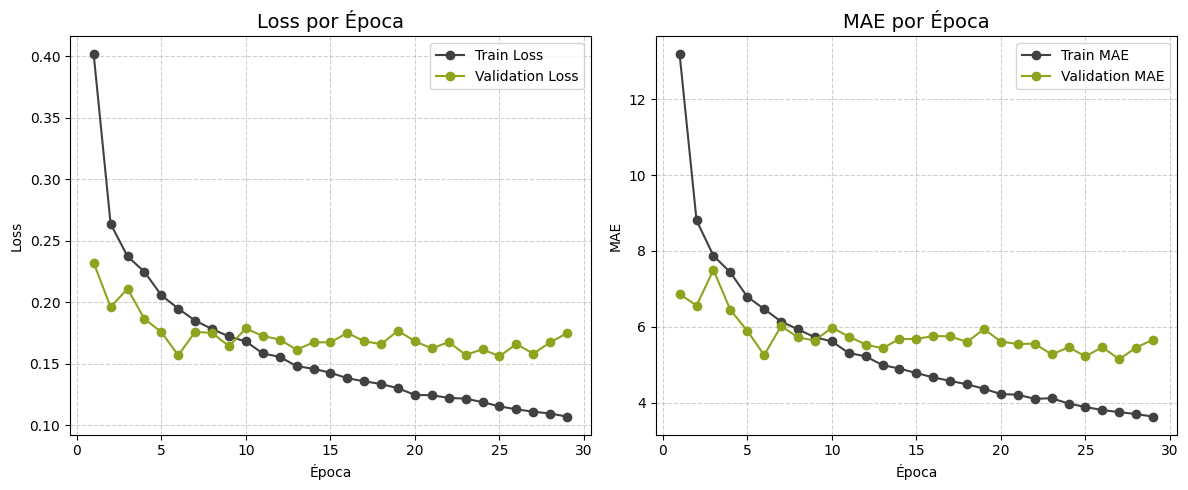

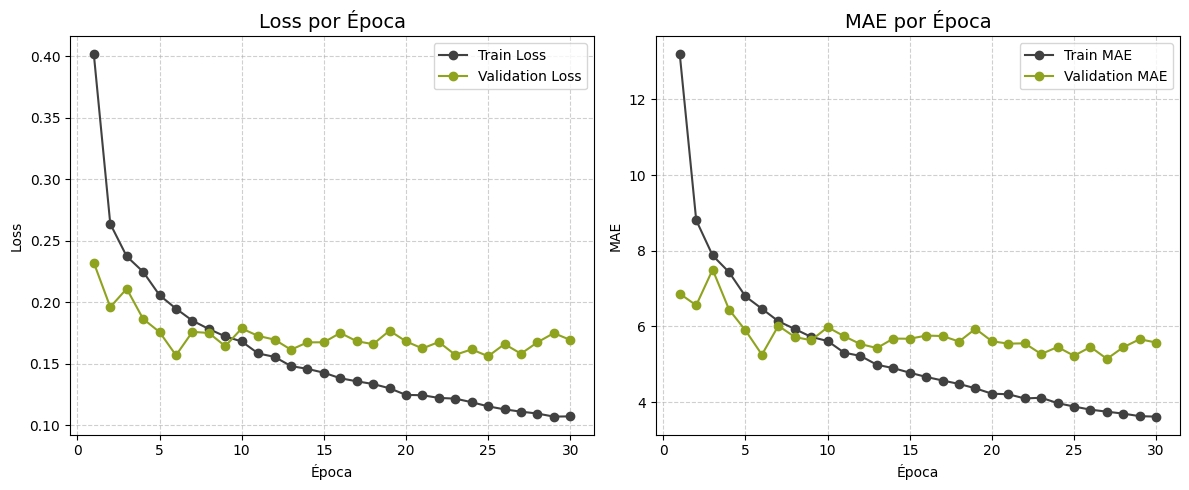

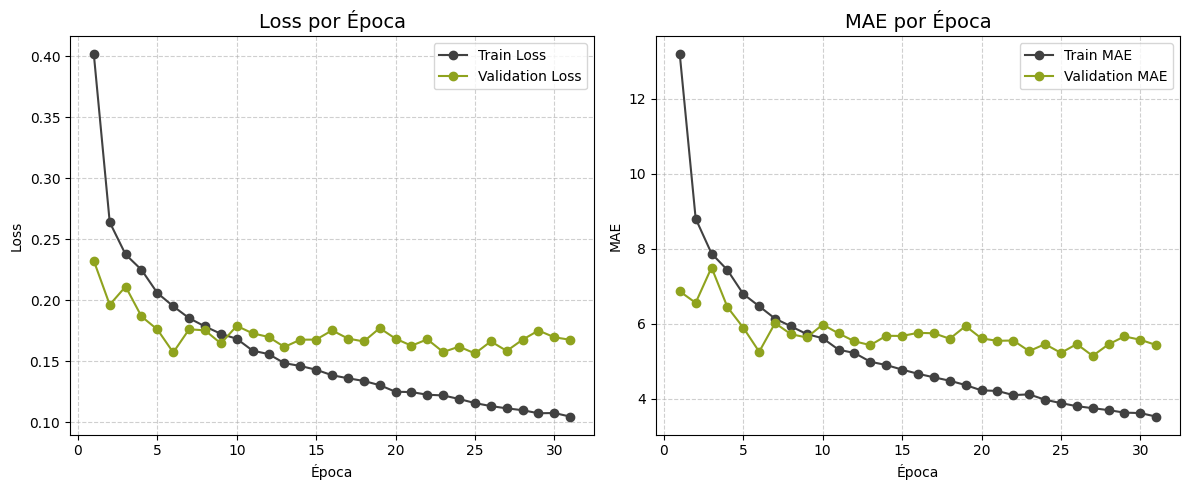

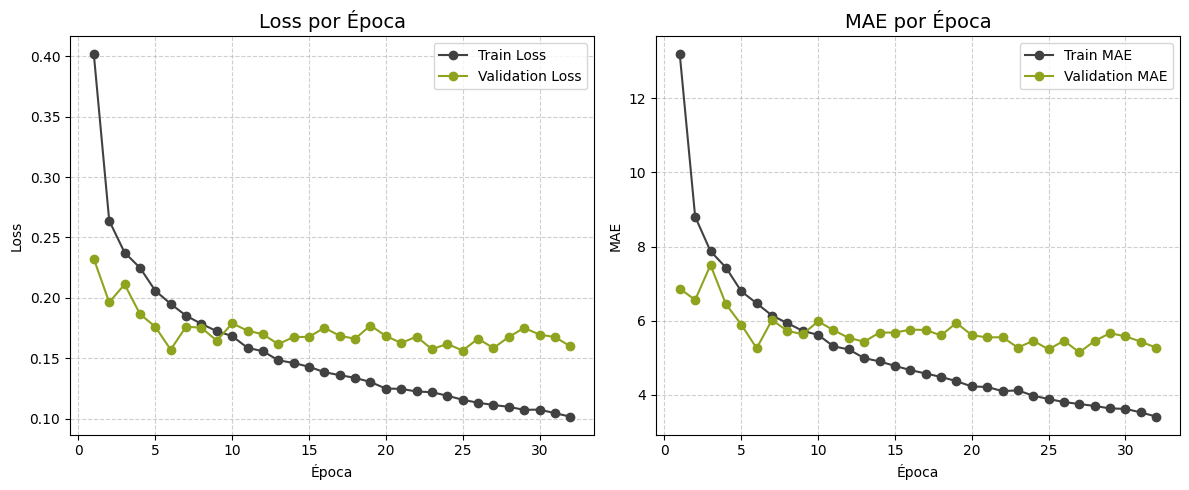

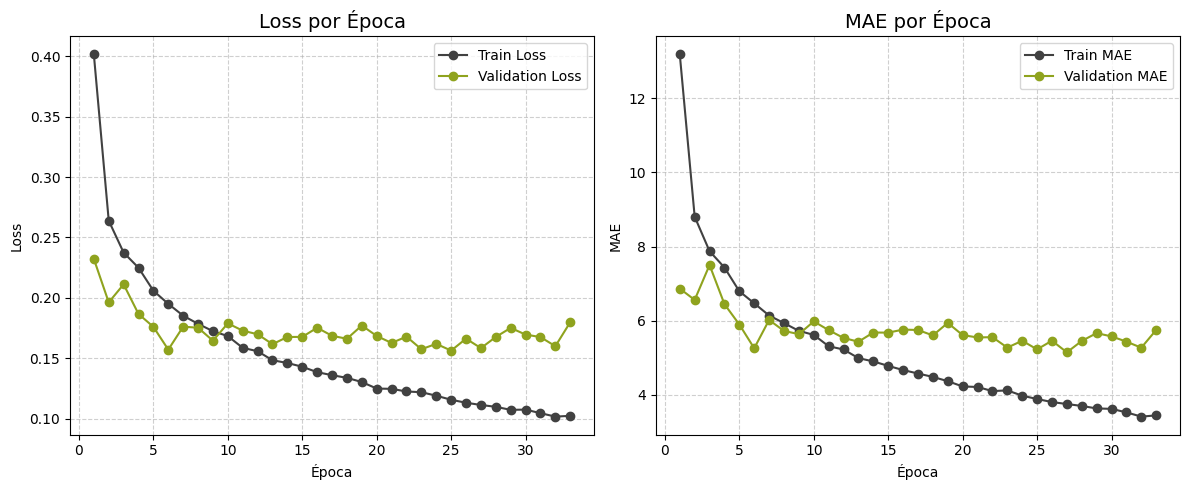

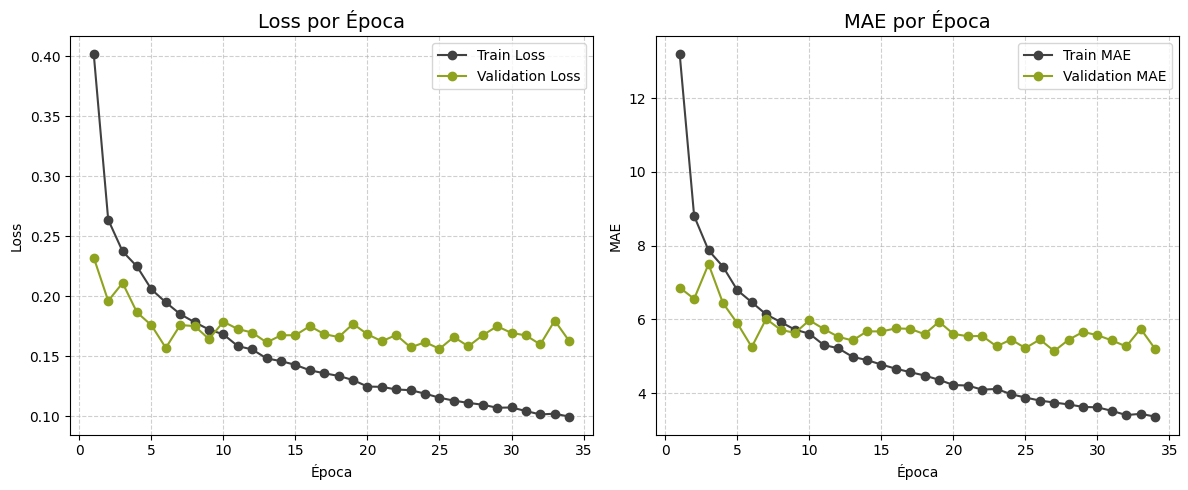

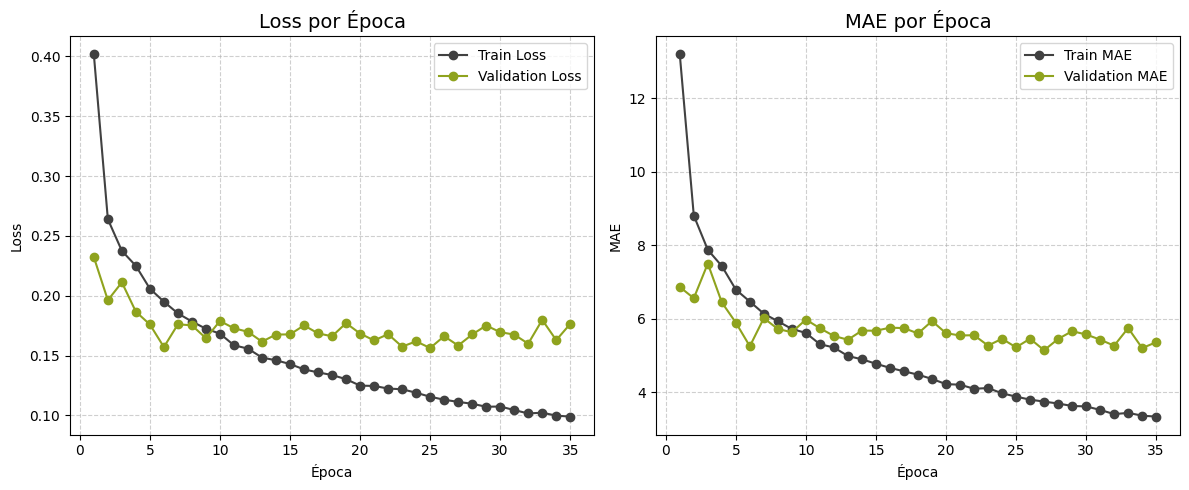

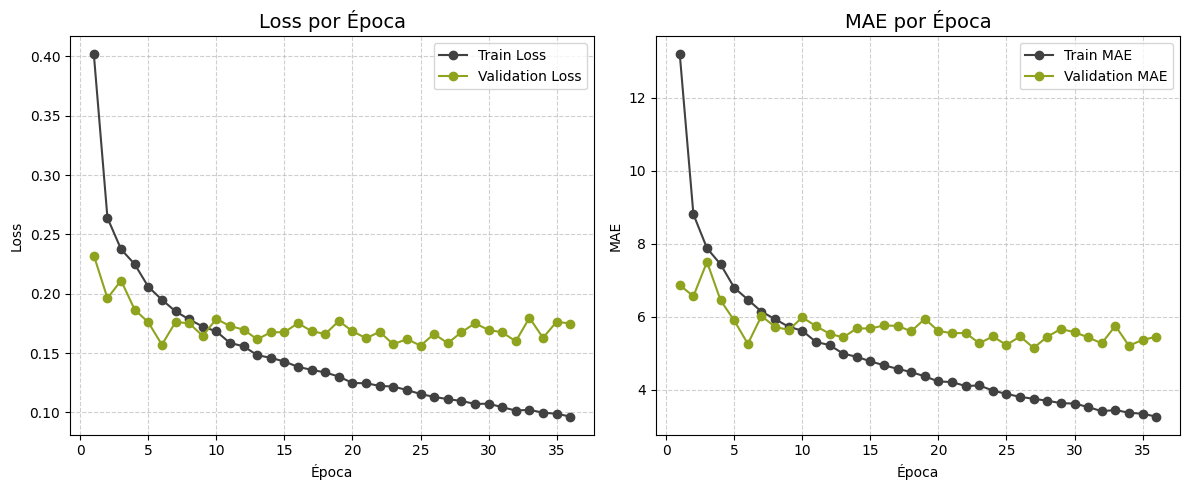

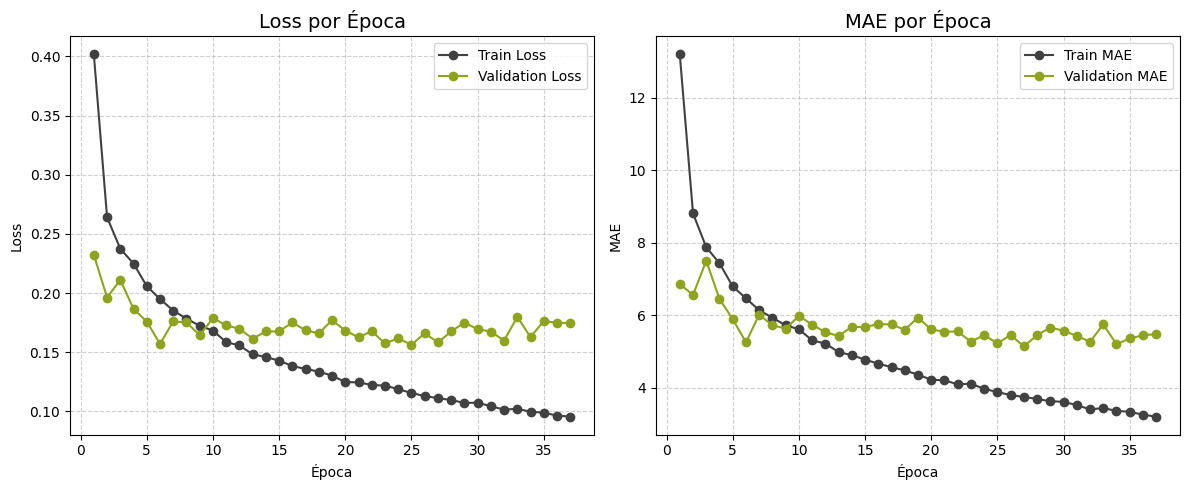

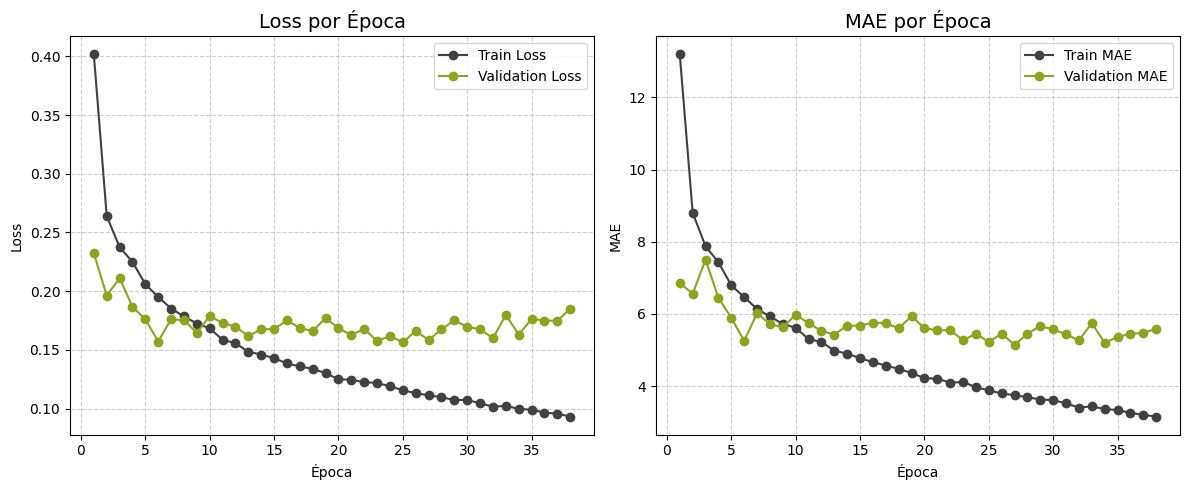

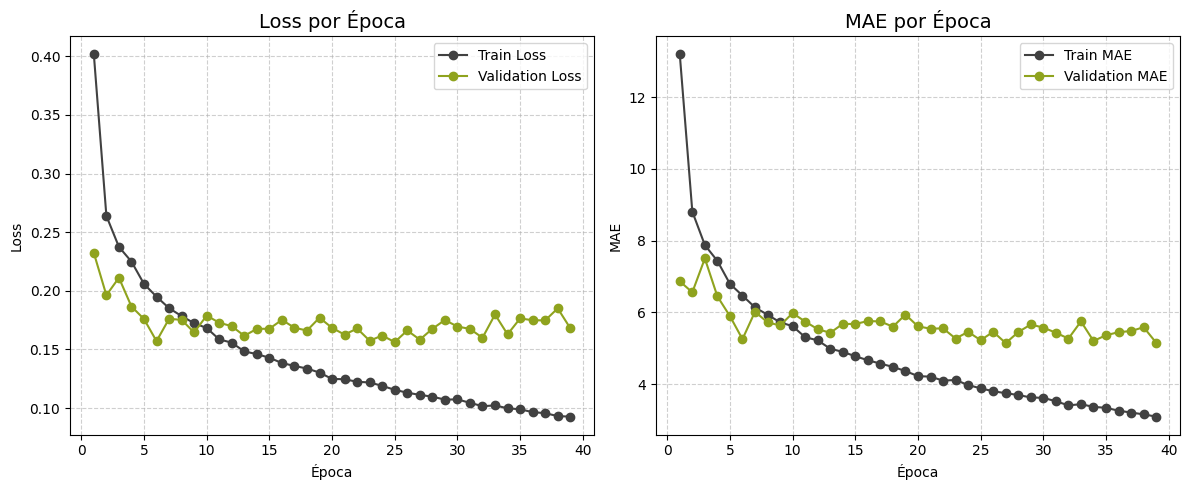

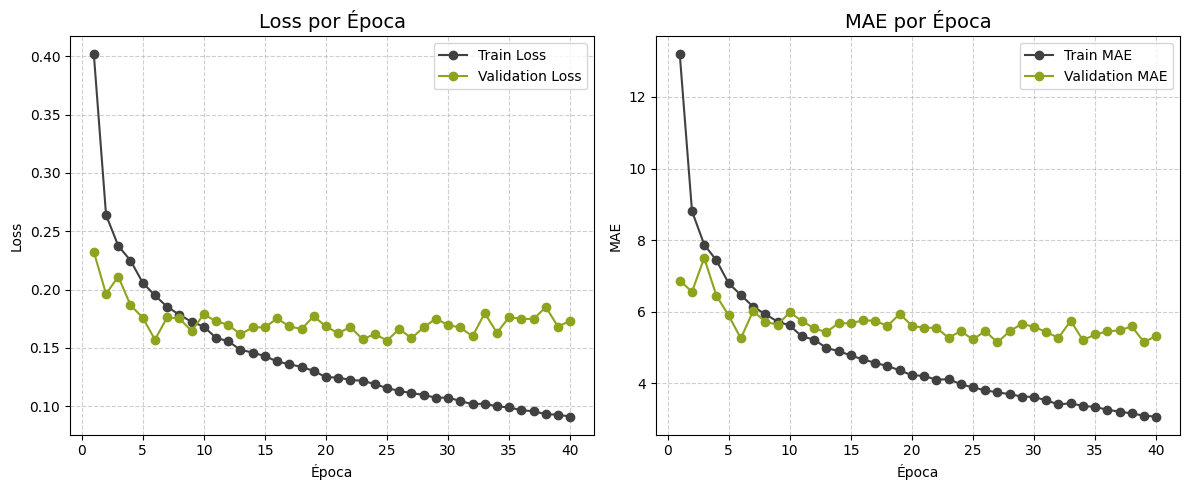

In [ ]:
device = "cuda"
model = CoralEfficientNetV2(max_age=80).to(device)
optimizer = AdamW(model.parameters(), lr = LEARNING_RATE, weight_decay = 1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5)

train_losses = []
val_losses = []
train_maes = []
val_maes = []

for epoch in range(EPOCHS):
    print(f'Epoca {epoch+1}/{EPOCHS}')
    train_loss, train_mae = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_mae = val_epoch(model, val_loader, device)

    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_maes.append(train_mae)
    val_maes.append(val_mae)
    


    print(f'Train Loss: {train_loss:.4f}\tTrain MAE: {train_mae:.4f}')
    print(f'Val Loss: {val_loss:.4f}\tVal MAE: {val_mae:.4f}')
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}\n")
    plot_training_curves(train_losses, val_losses, train_maes, val_maes, save_path = './plots/efficientNetL_learning_curve.png')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'val_mae': val_mae,
    }, f'./model_history/EfficientNetL/model_epoch_{epoch+1}.pth')


In [12]:
device = "cuda"
model = CoralEfficientNetV2(max_age=80).to(device)
checkpoint = torch.load('./model_history/EfficientNetL/model_epoch_6.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [13]:

test_loss, test_mae = val_epoch(model, test_loader, device)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 5.3955


In [ ]:
def coral_predict(logits):
    """
    logits: tensor shape (batch, K) donde K = num_classes - 1
    Retorna: edad predicha shape (batch,)
    """
    prob = torch.sigmoid(logits) 

    pred = torch.sum(prob > 0.5, dim=1)

    return pred


def predict_all_coral(model, loader, device):
    model.eval()
    
    all_true = []
    all_pred = []

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Predicting (CORAL)"):

            imgs = imgs.to(device)
            

            targets = targets.numpy()  

            logits = model(imgs) 

            pred_age_batch = coral_predict(logits).cpu().numpy()

            true_age_batch = coral_decode(targets)

            all_pred.extend(pred_age_batch)
            all_true.extend(true_age_batch)

    return np.array(all_true), np.array(all_pred)

def coral_decode(ordinal_vectors):
    return np.sum(ordinal_vectors > 0.5, axis=1)



In [18]:
y_true, y_pred = predict_all_coral(model, test_loader, device)

test_df = test_df.reset_index(drop=True).copy()
test_df["true_age"] = y_true
test_df["pred_age"] = y_pred
test_df["abs_error"] = np.abs(test_df["true_age"] - test_df["pred_age"])


Predicting (CORAL): 100%|██████████| 255/255 [00:51<00:00,  4.95it/s]


In [19]:
def get_race(race):
    if race == 0:
        return 'White'
    elif race == 1:
        return 'Black'
    elif race == 2:
        return 'Asian'
    elif race == 3:
        return 'Indian'
    else:
        return "Other"
    
import numpy as np

In [20]:
test_df['gender'] = np.where(test_df['gender'] == 0, 'Male', 'Female')
test_df['race'] = test_df['race'].apply(lambda x: get_race(x))


In [21]:
mae_by_gender = test_df.groupby("gender")["abs_error"].mean()
mae_by_race = test_df.groupby("race")["abs_error"].mean()

print("MAE por género:\n", mae_by_gender)
print("\nMAE por raza:\n", mae_by_race)


MAE por género:
 gender
Female    5.556311
Male      5.226957
Name: abs_error, dtype: float64

MAE por raza:
 race
Asian     3.929619
Black     6.096852
Indian    5.260465
Other     5.346591
White     5.667785
Name: abs_error, dtype: float64


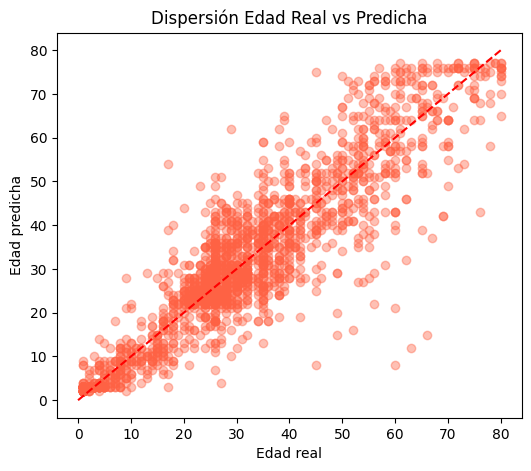

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(test_df["true_age"], test_df["pred_age"], alpha=0.4, color = '#FE6244')
plt.xlabel("Edad real")
plt.ylabel("Edad predicha")
plt.title("Dispersión Edad Real vs Predicha")
plt.plot([0,80],[0,80],"r--")  
plt.show()


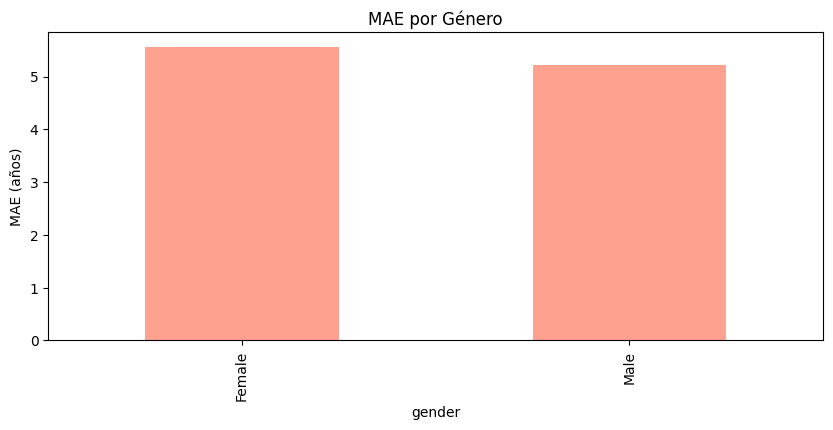

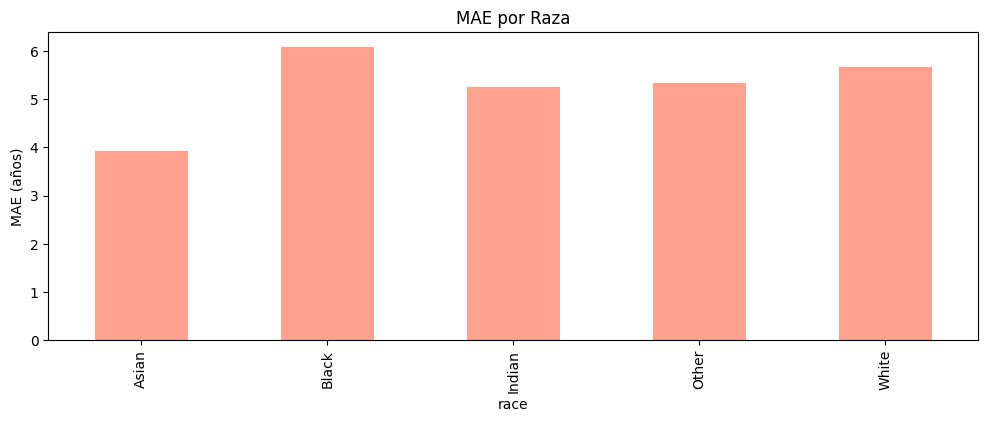

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
mae_by_gender.plot(kind='bar', color='#FE6244', alpha = .6)
plt.ylabel("MAE (años)")
plt.title("MAE por Género")
plt.show()

plt.figure(figsize=(12,4))
mae_by_race.plot(kind='bar', color='#FE6244', alpha = .6)
plt.ylabel("MAE (años)")
plt.title("MAE por Raza")
plt.show()
